## HW4 - CORDIC 

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Result 1 - Find S(N) versus N

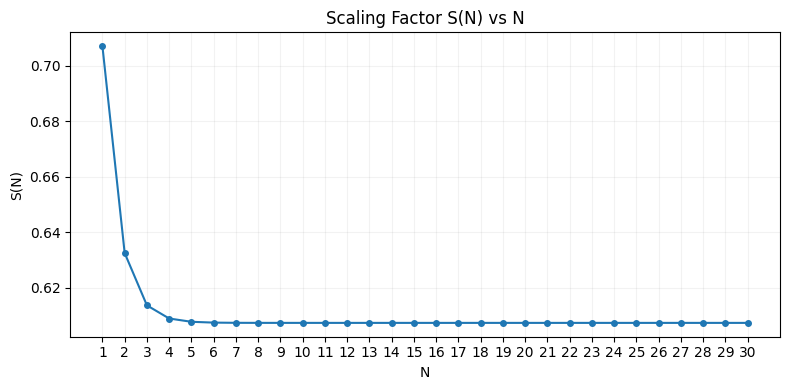

In [102]:
N_max = 30
N_values = np.arange(1, N_max + 1)
S_values = []

for N in N_values:
    product = 1.0
    for i in range(N):
        product *= np.sqrt(1 + 2**(-2*i))
    S_values.append(1.0 / product) # S(N) = 1 / Product

plt.figure(figsize=(8, 4))
plt.plot(N_values, S_values, marker='o', markersize=4)
plt.xlabel('N')
plt.ylabel('S(N)')
plt.title('Scaling Factor S(N) vs N')
plt.xticks(N_values)
plt.grid(True, color='gray', alpha=0.1)
plt.tight_layout()
plt.show()

### Result 2 - Average Absolute Phase Error vs Fractional Wordlength
找 X 跟 Y 應該要用多少定點數位元才能夠滿足門檻

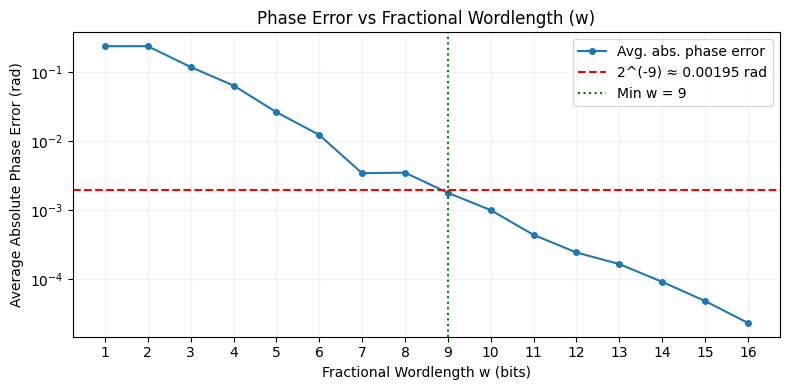

Minimum w satisfying avg error < 2^(-9): w = 9
Total bits per sample: w+2 = 11  (1 sign + 1 integer + 9 fractional)


In [ ]:
# Parameters: I=9, beta = mod(9,2)+1 = 2
beta = 2
m_values = np.arange(10)
alpha_m = (4*m_values + beta) / 20 * np.pi

# True inputs (floating-point)
X_true = np.cos(alpha_m)
Y_true = np.sin(alpha_m)

# Reference phase : arctan2 function 方便我們去看象限 
phase_ref = np.arctan2(Y_true, X_true)

# Quantization : 對 X 跟 Y 做指定 w 位元寬度的量化
# 由於 X 跟 Y 在 [-1,1]，而增益 K(N) 最大為約 1 / 0.6 = 1.67 < 2，因此整數位元為 1 
def quantize(val, w):
    return np.floor(val * 2 **(w)) / 2 **(w)

# CORDIC phase computation (integer shift version, hardware-accurate)
def cordic_phase(X0, Y0, w_xy, N, w_theta=None):
    phase_adjust = 0.0

    if X0 < 0: # 代表在第二或是第三象限

        # 如果在第二象限 phase_adjust = pi，第三象限 phase_adjust = -pi
        phase_adjust = np.pi if Y0 >= 0 else -np.pi

        # 全部取負，旋轉 180 度
        X0, Y0 = -X0, -Y0

    # 量化輸入並轉成整數表示 (模擬硬體暫存器)
    Xi = int(np.floor(X0 * 2**w_xy))
    Yi = int(np.floor(Y0 * 2**w_xy))

    theta = 0.0

    for i in range(N):
        mu = -1 if Yi > 0 else 1
        elem_angle = np.arctan(2.0**(-i))
        if w_theta is not None:
            elem_angle = quantize(elem_angle, w_theta)  # 量化基本角度

        # 注意這裡的量化要使用算數右移，因為在後面硬體實作的時候我們會用 Shifter 取代乘法器
        dX = Yi >> i 
        dY = Xi >> i
        
        # 前面算出來是整數，直接加減就好，不需要再量化了
        Xi_new = Xi - mu * dX 
        Yi_new = Yi + mu * dY

        theta = theta - mu * elem_angle
        if w_theta is not None:
            theta = quantize(theta, w_theta)  # 量化 theta 累加器 

        Xi = Xi_new
        Yi = Yi_new

    return theta + phase_adjust

# Sweep w = 1..16, N = 20
N_iter = 20
w_values = np.arange(1, 17)
avg_errors = []

for w in w_values:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], w, N_iter) - phase_ref[m])
              for m in range(10)]
    avg_errors.append(np.mean(errors))

avg_errors = np.array(avg_errors)

# Find minimum w satisfying error < 2^(-9)
threshold = 2.0**(-9)
valid_w = w_values[avg_errors < threshold]
min_w = int(valid_w[0]) if len(valid_w) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_values, avg_errors, marker='o', markersize=4, label='Avg. abs. phase error')
plt.axhline(threshold, color='r', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_w is not None:
    plt.axvline(min_w, color='g', linestyle=':', label=f'Min w = {min_w}')
plt.xlabel('Fractional Wordlength w (bits)')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title('Phase Error vs Fractional Wordlength (w)')
plt.xticks(w_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

# Integer wordlength analysis
K_N = math.prod(math.sqrt(1 + 2**(-2*i)) for i in range(N_iter))
print(f"Minimum w satisfying avg error < 2^(-9): w = {min_w}")
print(f"Total bits per sample: w+2 = {min_w+2}  (1 sign + 1 integer + {min_w} fractional)")

### Result 3

#### Phase Error vs Number of Micro-rotations
找跌代次數 S 到底要是多少才可以滿足門檻

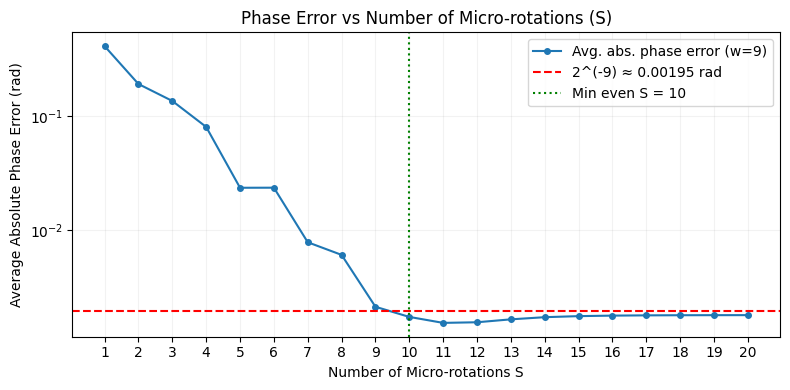

Minimum even S satisfying avg error < 2^(-9): S = 10


In [104]:
S_range = np.arange(1, 21) # sweep S = 1..20 
avg_errors_S = []

for S in S_range:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], min_w, S) - phase_ref[m])
              for m in range(10)]
    avg_errors_S.append(np.mean(errors))

avg_errors_S = np.array(avg_errors_S)

# Find minimum even S satisfying error < 2^(-9)
valid_S = S_range[(avg_errors_S < threshold) & (S_range % 2 == 0)]
min_S = int(valid_S[0]) if len(valid_S) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(S_range, avg_errors_S, marker='o', markersize=4, label=f'Avg. abs. phase error (w={min_w})')
plt.axhline(threshold, color='r', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_S is not None:
    plt.axvline(min_S, color='g', linestyle=':', label=f'Min even S = {min_S}')
plt.xlabel('Number of Micro-rotations S')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title(f'Phase Error vs Number of Micro-rotations (S)')
plt.xticks(S_range)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

print(f"Minimum even S satisfying avg error < 2^(-9): S = {min_S}")

#### Phase Error vs Elementary Angle Wordlength
找 Theta 的定點數位寬要是多少才能夠滿足門檻

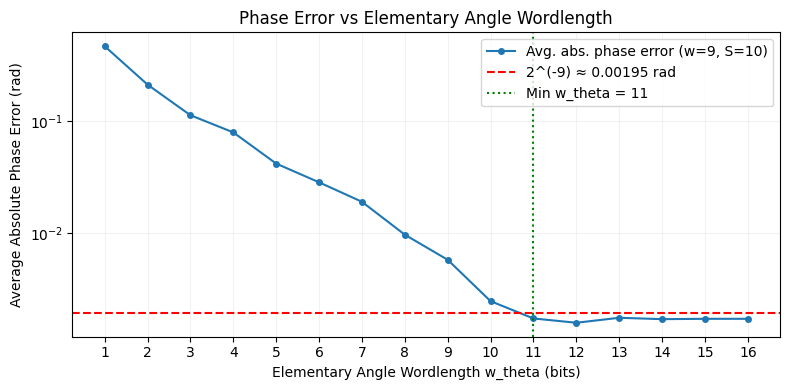

Minimum w_theta satisfying avg error < 2^(-9): w_theta = 11

Elementary Angles (S=10 stages):
  i        Float             Quantized             Binary
-----------------------------------------------------------------
  0    0.7853981634        0.7851562500         0.11001001000
  1    0.4636476090        0.4633789062         0.01110110101
  2    0.2449786631        0.2446289062         0.00111110101
  3    0.1243549945        0.1240234375         0.00011111110
  4    0.0624188100        0.0620117188         0.00001111111
  5    0.0312398334        0.0307617188         0.00000111111
  6    0.0156237286        0.0151367188         0.00000011111
  7    0.0078123411        0.0073242188         0.00000001111
  8    0.0039062301        0.0034179688         0.00000000111
  9    0.0019531225        0.0014648438         0.00000000011


In [105]:
w_theta_values = np.arange(1, 17) # sweep w_theta = 1..16
avg_errors_theta = []

for w_theta in w_theta_values:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], min_w, min_S, w_theta=w_theta) - phase_ref[m])
              for m in range(10)]
    avg_errors_theta.append(np.mean(errors))

avg_errors_theta = np.array(avg_errors_theta)

# Find minimum w_theta satisfying error < 2^(-9)
valid_w_theta = w_theta_values[avg_errors_theta < threshold]
min_w_theta = int(valid_w_theta[0]) if len(valid_w_theta) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_theta_values, avg_errors_theta, marker='o', markersize=4,
             label=f'Avg. abs. phase error (w={min_w}, S={min_S})')
plt.axhline(threshold, color='r', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_w_theta is not None:
    plt.axvline(min_w_theta, color='g', linestyle=':', label=f'Min w_theta = {min_w_theta}')
plt.xlabel('Elementary Angle Wordlength w_theta (bits)')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title(f'Phase Error vs Elementary Angle Wordlength')
plt.xticks(w_theta_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

print(f"Minimum w_theta satisfying avg error < 2^(-9): w_theta = {min_w_theta}")

# Table of elementary angles
print(f"\nElementary Angles (S={min_S} stages):")
print(f"{'i':>3} {'Float':>12}  {'Quantized':>20} {'Binary':>18}")
print("-" * 65)
for i in range(min_S):
    angle_f = np.arctan(2.0**(-i))
    angle_q = quantize(angle_f, min_w_theta)
    int_bits = int(angle_q * 2**min_w_theta)
    binary_str = '0.' + format(int_bits, f'0{min_w_theta}b')
    print(f"{i:>3}  {angle_f:>14.10f}  {angle_q:>18.10f}  {binary_str:>20}")

### Result 5 - CSD Representation of Scaling Factor S(N)
要把 Scaling Factor 轉換成 CSD 表示法

S(10) = 0.6072533211


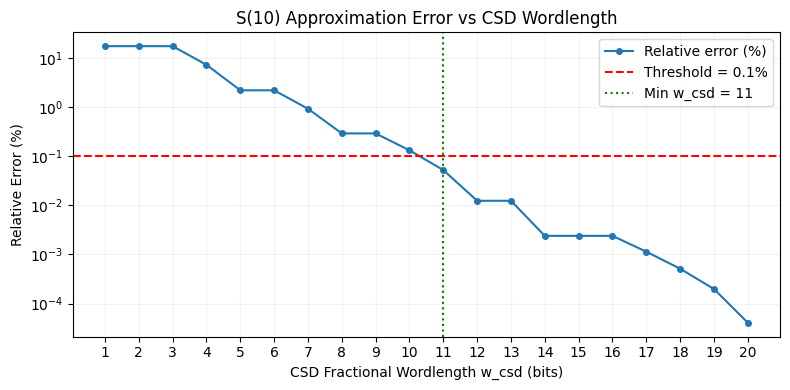


Minimum w_csd satisfying error < 0.1%: w_csd = 11
S_true  = 0.6072533211
S_csd   = 0.6069335938
Error   = 0.0527%

Shift-and-add block (S = 0.60693359375):
   Shift   Digit  Operation
  -----------------------------------
       1      +1  + (X >> 1)
       3      +1  + (X >> 3)
       6      -1  - (X >> 6)
       9      -1  - (X >> 9)
      11      -1  - (X >> 11)

Non-zero CSD digits : 5
Adders required     : 4

Summary of Wordlengths:
X and Y wordlength = 11 bits
Elementary angle wordlength w_theta = 11 bits
CSD approximation of S(10) with w_csd = 11 bits


In [106]:
# S(N) for N = 10
N_mag = 10
S_true = 1.0 / math.prod(math.sqrt(1 + 2**(-2*i)) for i in range(N_mag))
print(f"S({N_mag}) = {S_true:.10f}")

# CSD conversion (Non-Adjacent Form)
def to_csd(value, n_frac_bits):
    # 先把浮點數直接截斷成定點數
    n = int(np.floor(value * 2**n_frac_bits))
    digits = {}
    pos = -n_frac_bits                      # 記錄當前 bit 對應的位置，一開始為最後
    while n != 0:
        if n & 1:                           # 檢查最低位是否為 1 -> n is odd
            d = -1 if (n & 3) == 3 else 1   # 看最後兩位來決定 d 是 +1 (else) 還是 -1 (11)
            digits[pos] = d                 # 存入 digits 中
            n -= d                          # 消掉
        n >>= 1                             # 往下一位移動
        pos += 1                            # 位移後 pos 也要跟著增加

    # 把做完 CSD 轉換後的 digits 加總回來得到近似值，就可以用這個近似值去看誤差了
    csd_val = sum(d * 2.0**p for p, d in digits.items())  # 2.0 to allow negative exponents
    return csd_val, digits

threshold_csd = 0.1 
w_csd_values = np.arange(1, 21)
errors_csd = []

for w_csd in w_csd_values: # 找出 csd 的最小位元寬度
    S_csd, _ = to_csd(S_true, w_csd)
    errors_csd.append(abs(S_true - S_csd) / S_true * 100)

errors_csd = np.array(errors_csd)

# Find minimum w_csd satisfying error < 0.1%
valid_csd = w_csd_values[errors_csd < threshold_csd]
min_w_csd = int(valid_csd[0]) if len(valid_csd) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_csd_values, errors_csd, marker='o', markersize=4, label='Relative error (%)')
plt.axhline(threshold_csd, color='r', linestyle='--', label=f'Threshold = 0.1%')
if min_w_csd is not None:
    plt.axvline(min_w_csd, color='g', linestyle=':', label=f'Min w_csd = {min_w_csd}')
plt.xlabel('CSD Fractional Wordlength w_csd (bits)')
plt.ylabel('Relative Error (%)')
plt.title(f'S({N_mag}) Approximation Error vs CSD Wordlength')
plt.xticks(w_csd_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

# CSD representation and shift-and-add analysis
S_csd_final, digits_final = to_csd(S_true, min_w_csd)
nonzero = {p: d for p, d in digits_final.items() if d != 0}
n_nonzero = len(nonzero)

print(f"\nMinimum w_csd satisfying error < 0.1%: w_csd = {min_w_csd}")
print(f"S_true  = {S_true:.10f}")
print(f"S_csd   = {S_csd_final:.10f}")
print(f"Error   = {abs(S_true - S_csd_final) / S_true * 100:.4f}%")
print(f"\nShift-and-add block (S = {S_csd_final}):")
print(f"  {'Shift':>6}  {'Digit':>6}  Operation")
print("  " + "-" * 35)
for p in sorted(nonzero.keys(), reverse=True):
    d = nonzero[p]
    shift = -p   # bit position -k → right shift by k
    sign = "+" if d == 1 else "-"
    print(f"  {shift:>6}  {d:>+6}  {sign} (X >> {shift})")
print(f"\nNon-zero CSD digits : {n_nonzero}")
print(f"Adders required     : {n_nonzero - 1}")


# 整理一下定點數位寬的結果，方便後續分析
print(f"\nSummary of Wordlengths:")
print(f"X and Y wordlength = {min_w + 2} bits")
print(f"Elementary angle wordlength w_theta = {min_w_theta} bits")
print(f"CSD approximation of S({N_mag}) with w_csd = {min_w_csd} bits")